# 01 — Data Exploration

Visual validation of the three BTCUSDT timeframes downloaded and cleaned in Week 1.

**Timeframes:** 1D · 4H · 1W  
**Purpose:** Confirm data integrity before building indicators.

In [1]:
# Cell 1 — Setup
import sys
from pathlib import Path

# Resolve project root (two levels up from notebooks/)
project_root = Path.cwd().parent
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (14, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

from btc_quant.data.storage import ParquetStorage

BASE_PATH = str(project_root / "data" / "processed")
storage = ParquetStorage()

df_1d = storage.load("BTCUSDT", "1d", BASE_PATH)
df_4h = storage.load("BTCUSDT", "4h", BASE_PATH)
df_1w = storage.load("BTCUSDT", "1w", BASE_PATH)

print(f"1D : {len(df_1d):>6,} rows | {df_1d['timestamp_utc'].min().date()} → {df_1d['timestamp_utc'].max().date()}")
print(f"4H : {len(df_4h):>6,} rows | {df_4h['timestamp_utc'].min().date()} → {df_4h['timestamp_utc'].max().date()}")
print(f"1W : {len(df_1w):>6,} rows | {df_1w['timestamp_utc'].min().date()} → {df_1w['timestamp_utc'].max().date()}")

2026-05-07 23:35:02.955 | INFO     | btc_quant.data.storage:load:123 - Loaded 3185 rows ← /Users/roger/Desktop/btc-quant/data/processed/btcusdt_1d.parquet


2026-05-07 23:35:02.969 | INFO     | btc_quant.data.storage:load:123 - Loaded 19113 rows ← /Users/roger/Desktop/btc-quant/data/processed/btcusdt_4h.parquet


2026-05-07 23:35:02.979 | INFO     | btc_quant.data.storage:load:123 - Loaded 454 rows ← /Users/roger/Desktop/btc-quant/data/processed/btcusdt_1w.parquet


1D :  3,185 rows | 2017-08-17 → 2026-05-06
4H : 19,113 rows | 2017-08-17 → 2026-05-07
1W :    454 rows | 2017-08-21 → 2026-04-27


## 1 — Schema & Integrity

In [2]:
# Cell 2 — Schema validation
for label, df in [("1D", df_1d), ("4H", df_4h), ("1W", df_1w)]:
    synth = int(df["is_synthetic"].sum())
    print(f"\n{'='*55}")
    print(f"  {label}  shape={df.shape}  synthetic={synth}")
    print(f"{'='*55}")
    print(df.dtypes.to_string())
    print("\n--- head ---")
    display(df.head(3))
    print("--- tail ---")
    display(df.tail(3))


  1D  shape=(3185, 10)  synthetic=0
timestamp_utc     datetime64[ns, UTC]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
close_time_utc    datetime64[ns, UTC]
quote_volume                  float64
num_trades                      int64
is_synthetic                     bool

--- head ---


,timestamp_utc,open,high,low,close,volume,close_time_utc,quote_volume,num_trades,is_synthetic
0,2017-08-17 00:00:00+00:00,4261.48,4485.39,4200.74,4285.08,795.150377,2017-08-17 23:59:59.999000+00:00,3.454770e+06,3427,False
1,2017-08-18 00:00:00+00:00,4285.08,4371.52,3938.77,4108.37,1199.888264,2017-08-18 23:59:59.999000+00:00,5.086958e+06,5233,False
2,2017-08-19 00:00:00+00:00,4108.37,4184.69,3850.00,4139.98,381.309763,2017-08-19 23:59:59.999000+00:00,1.549484e+06,2153,False


--- tail ---


,timestamp_utc,open,high,low,close,volume,close_time_utc,quote_volume,num_trades,is_synthetic
3182,2026-05-04 00:00:00+00:00,78568.58,80776.99,78202.00,79861.01,26042.96135,2026-05-04 23:59:59.999000+00:00,2.074175e+09,3734604,False
3183,2026-05-05 00:00:00+00:00,79861.01,81791.48,79808.72,80905.52,16947.17995,2026-05-05 23:59:59.999000+00:00,1.374319e+09,2490930,False
3184,2026-05-06 00:00:00+00:00,80905.53,82850.00,80731.14,81447.01,18798.77396,2026-05-06 23:59:59.999000+00:00,1.535651e+09,2794707,False



  4H  shape=(19113, 10)  synthetic=16
timestamp_utc     datetime64[ns, UTC]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
close_time_utc    datetime64[ns, UTC]
quote_volume                  float64
num_trades                      int64
is_synthetic                     bool

--- head ---


...

,timestamp_utc,open,high,low,close,volume,close_time_utc,quote_volume,num_trades,is_synthetic
19110,2026-05-07 04:00:00+00:00,80834.92,81708.32,80725.09,81518.58,2038.83969,2026-05-07 07:59:59.999000+00:00,1.656154e+08,310508,False
19111,2026-05-07 08:00:00+00:00,81518.57,81590.00,80572.40,80866.65,2364.09693,2026-05-07 11:59:59.999000+00:00,1.915933e+08,327251,False
19112,2026-05-07 12:00:00+00:00,80866.65,81180.00,79699.52,79890.63,4826.66306,2026-05-07 15:59:59.999000+00:00,3.878357e+08,699919,False



  1W  shape=(454, 10)  synthetic=0
timestamp_utc     datetime64[ns, UTC]
open                          float64
high                          float64
low                           float64
close                         float64
volume                        float64
close_time_utc    datetime64[ns, UTC]
quote_volume                  float64
num_trades                      int64
is_synthetic                     bool

--- head ---


,timestamp_utc,open,high,low,close,volume,close_time_utc,quote_volume,num_trades,is_synthetic
0,2017-08-21 00:00:00+00:00,4069.13,4453.91,3400.00,4310.01,4599.396629,2017-08-27 23:59:59.999000+00:00,1.897898e+07,37826,False
1,2017-08-28 00:00:00+00:00,4310.01,4939.19,4124.54,4509.08,4753.843376,2017-09-03 23:59:59.999000+00:00,2.158168e+07,35717,False
2,2017-09-04 00:00:00+00:00,4505.00,4788.59,3603.00,4130.37,6382.787745,2017-09-10 23:59:59.999000+00:00,2.730782e+07,42372,False


--- tail ---


,timestamp_utc,open,high,low,close,volume,close_time_utc,quote_volume,num_trades,is_synthetic
451,2026-04-13 00:00:00+00:00,70741.56,78333.00,70566.99,73801.79,128729.92407,2026-04-19 23:59:59.999000+00:00,9.622709e+09,24088699,False
452,2026-04-20 00:00:00+00:00,73801.80,79472.82,73724.31,78657.55,94938.10789,2026-04-26 23:59:59.999000+00:00,7.327313e+09,19374163,False
453,2026-04-27 00:00:00+00:00,78657.55,79485.66,74937.52,78568.57,88811.52864,2026-05-03 23:59:59.999000+00:00,6.862937e+09,15614780,False


## 2 — Price History (log scale)

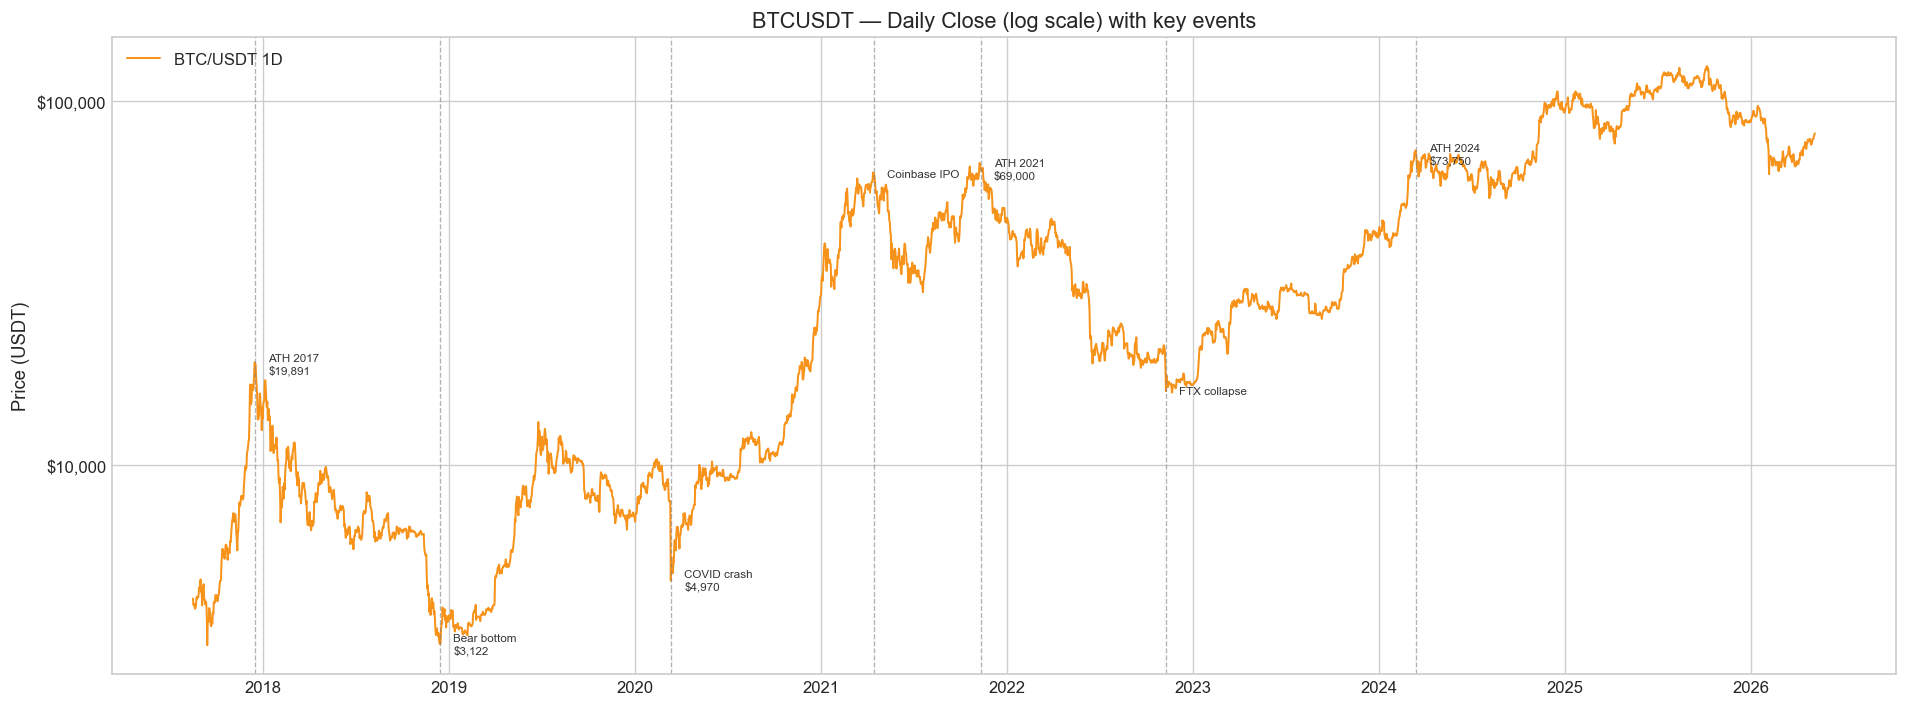

In [3]:
# Cell 3 — Log price chart with event annotations
EVENTS = [
    ("2017-12-17", "ATH 2017\n$19,891"),
    ("2018-12-15", "Bear bottom\n$3,122"),
    ("2020-03-12", "COVID crash\n$4,970"),
    ("2021-04-14", "Coinbase IPO"),
    ("2021-11-10", "ATH 2021\n$69,000"),
    ("2022-11-09", "FTX collapse"),
    ("2024-03-14", "ATH 2024\n$73,750"),
]

fig, ax = plt.subplots(figsize=(16, 6))
ax.semilogy(df_1d["timestamp_utc"], df_1d["close"], lw=1.2, color="#F7931A", label="BTC/USDT 1D")
ax.set_title("BTCUSDT — Daily Close (log scale) with key events")
ax.set_ylabel("Price (USDT)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for date_str, label in EVENTS:
    dt = pd.Timestamp(date_str, tz="UTC")
    candidates = df_1d[df_1d["timestamp_utc"] >= dt]
    if len(candidates) == 0:
        continue
    row = candidates.iloc[0]
    ax.axvline(dt, color="gray", lw=0.8, linestyle="--", alpha=0.6)
    ax.annotate(
        label, xy=(dt, row["close"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=7, va="center", color="#333333",
    )

ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## 3 — Price History (linear scale)

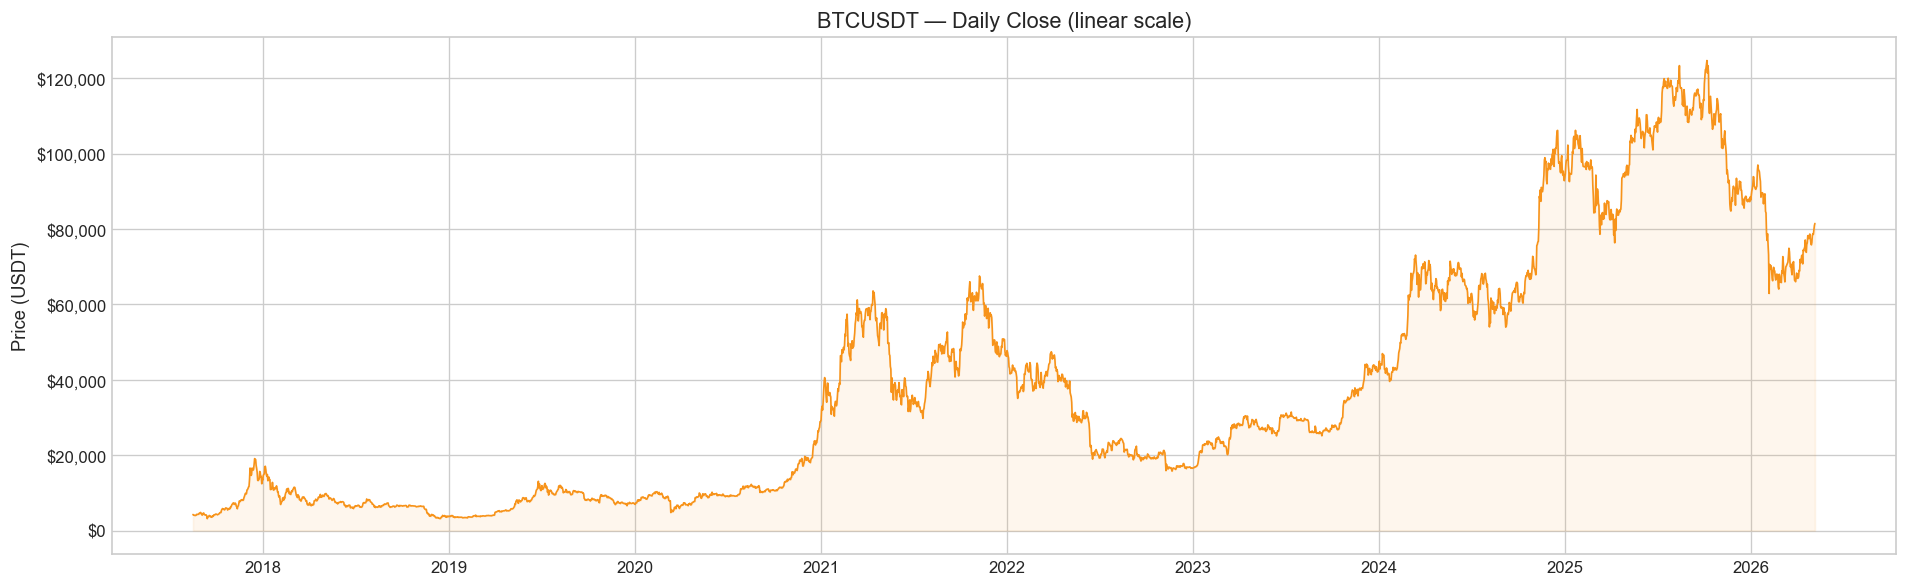

In [4]:
# Cell 4 — Linear price chart
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_1d["timestamp_utc"], df_1d["close"], lw=1.0, color="#F7931A")
ax.fill_between(df_1d["timestamp_utc"], df_1d["close"], alpha=0.08, color="#F7931A")
ax.set_title("BTCUSDT — Daily Close (linear scale)")
ax.set_ylabel("Price (USDT)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

## 4 — Volume History

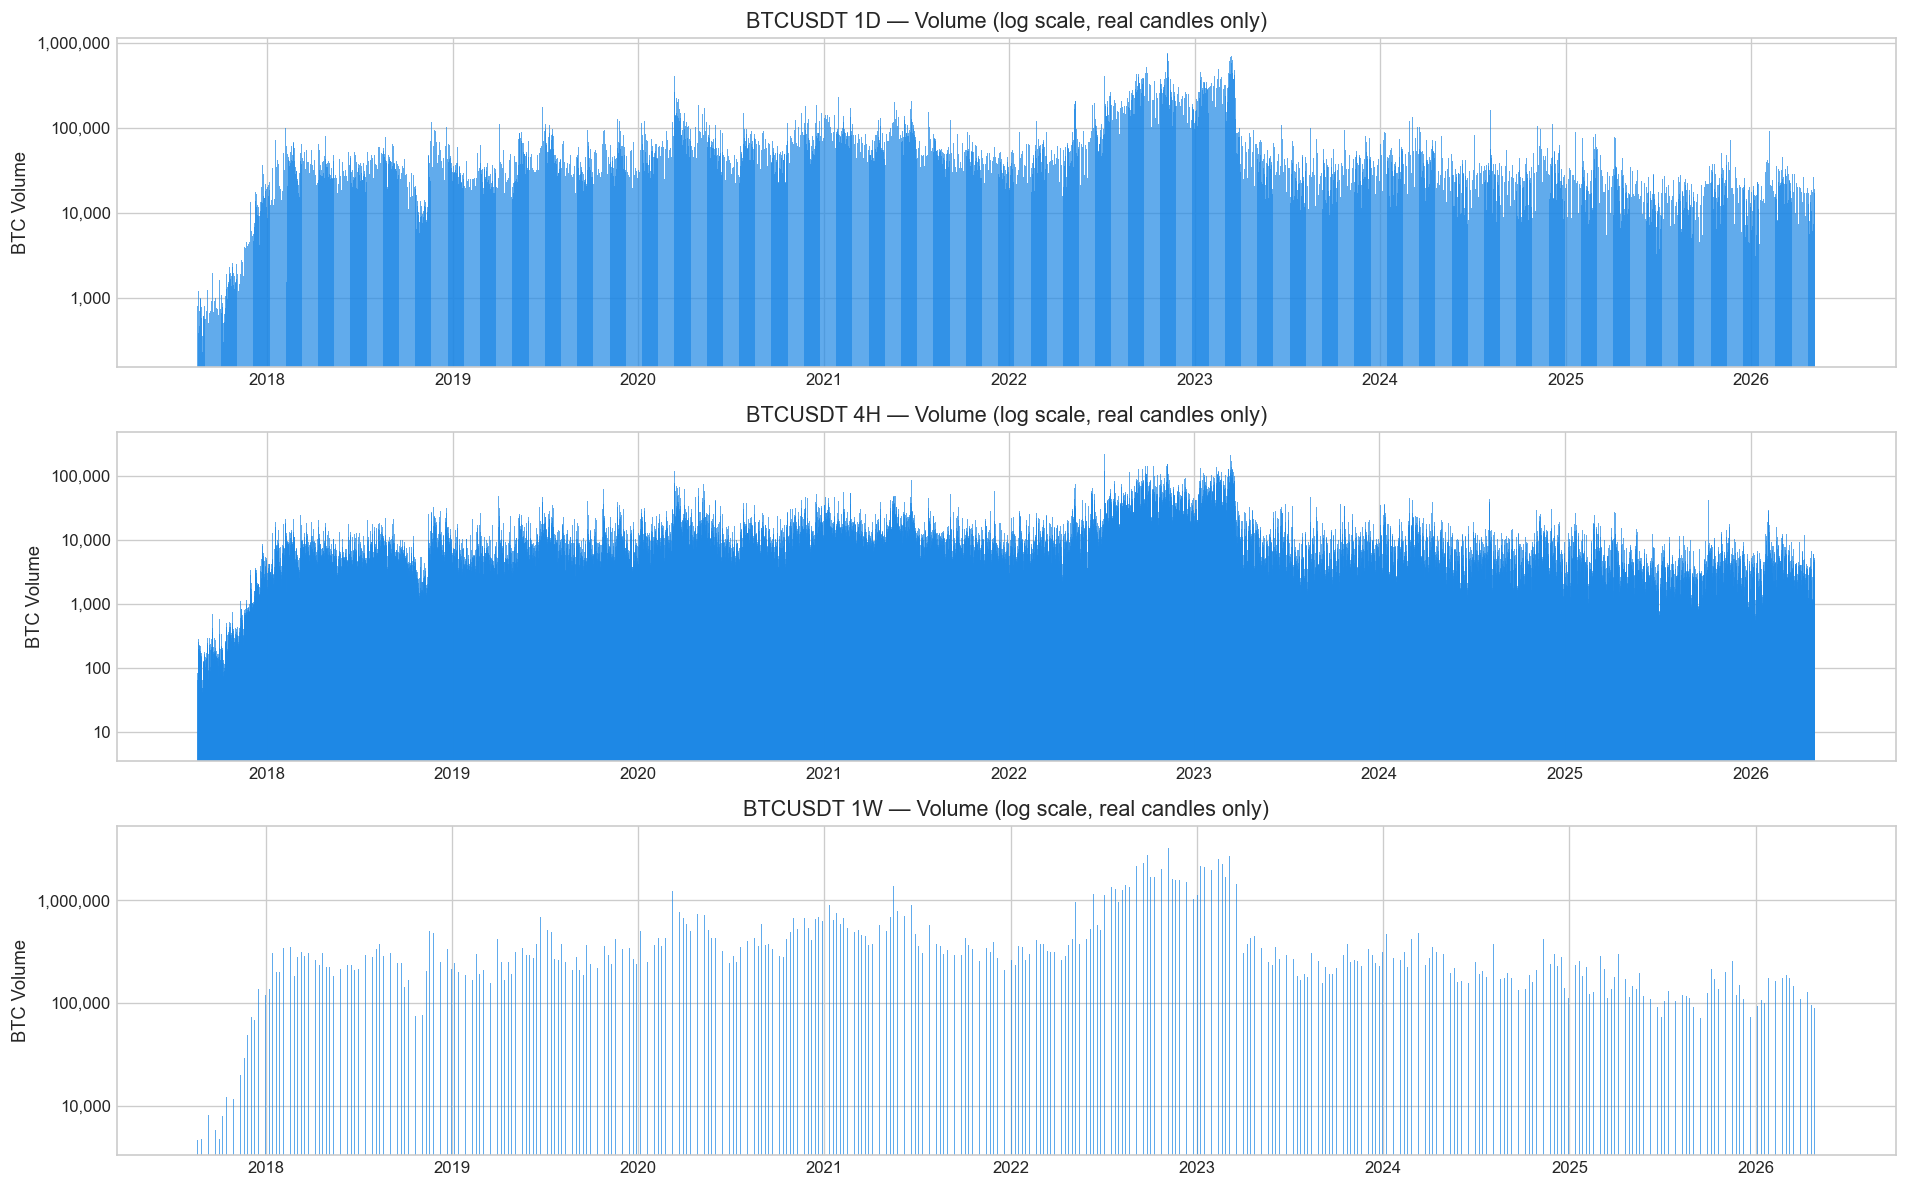

In [5]:
# Cell 5 — Volume history (log scale)
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, (label, df) in zip(axes, [("1D", df_1d), ("4H", df_4h), ("1W", df_1w)]):
    real = df[~df["is_synthetic"]]
    ax.bar(real["timestamp_utc"], real["volume"], width=1.5, color="#1E88E5", alpha=0.7)
    ax.set_yscale("log")
    ax.set_title(f"BTCUSDT {label} — Volume (log scale, real candles only)")
    ax.set_ylabel("BTC Volume")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.tight_layout()
plt.show()

## 5 — Returns Distribution

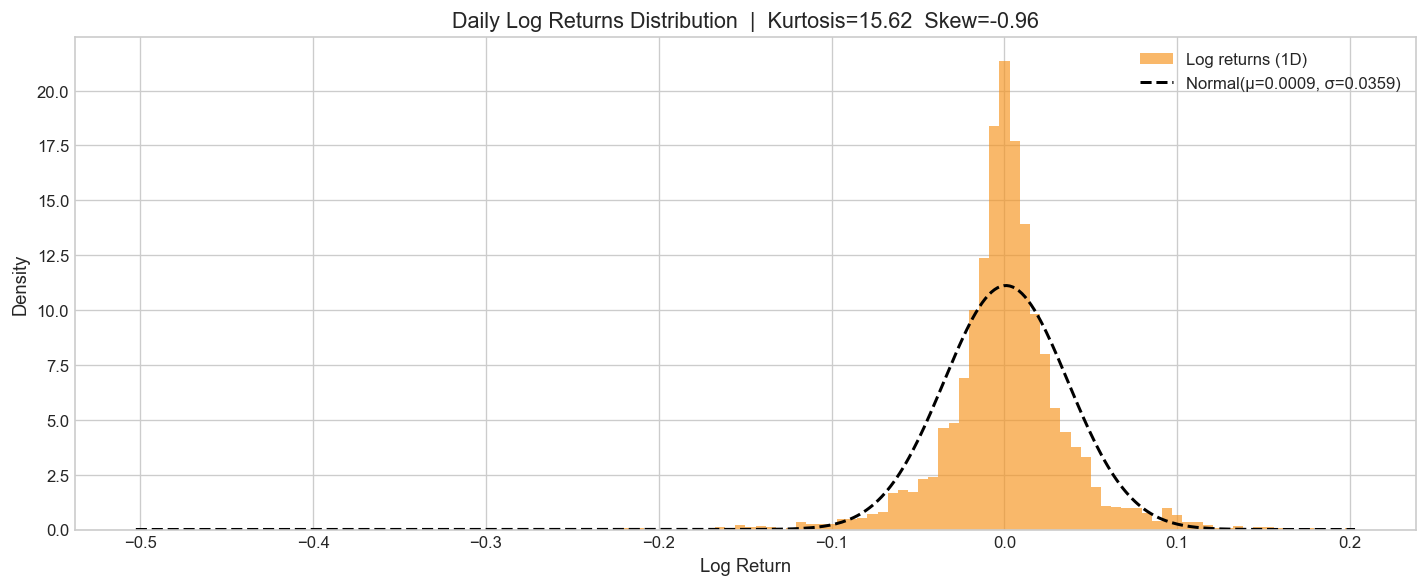


Moves > 3σ (0.108): 51 days (1.60%)
Expected under normality: 0.27%
Fat tail factor: 5.9x


In [6]:
# Cell 6 — Daily returns distribution + normal overlay (fat tails check)
real_1d = df_1d[~df_1d["is_synthetic"]].copy()
returns = np.log(real_1d["close"] / real_1d["close"].shift(1)).dropna()

mu, sigma = returns.mean(), returns.std()
kurt = float(returns.kurtosis())
skew = float(returns.skew())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(returns, bins=120, density=True, color="#F7931A", alpha=0.65, label="Log returns (1D)")

x = np.linspace(returns.min(), returns.max(), 400)
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax.plot(x, normal_pdf, "k--", lw=1.8, label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")

ax.set_title(f"Daily Log Returns Distribution  |  Kurtosis={kurt:.2f}  Skew={skew:.2f}")
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
plt.show()

threshold = 3 * sigma
big_moves = returns[returns.abs() > threshold]
print(f"\nMoves > 3σ ({threshold:.3f}): {len(big_moves)} days ({100*len(big_moves)/len(returns):.2f}%)")
print(f"Expected under normality: {100*0.0027:.2f}%")
print(f"Fat tail factor: {(len(big_moves)/len(returns))/0.0027:.1f}x")

## 6 — Drawdown from ATH

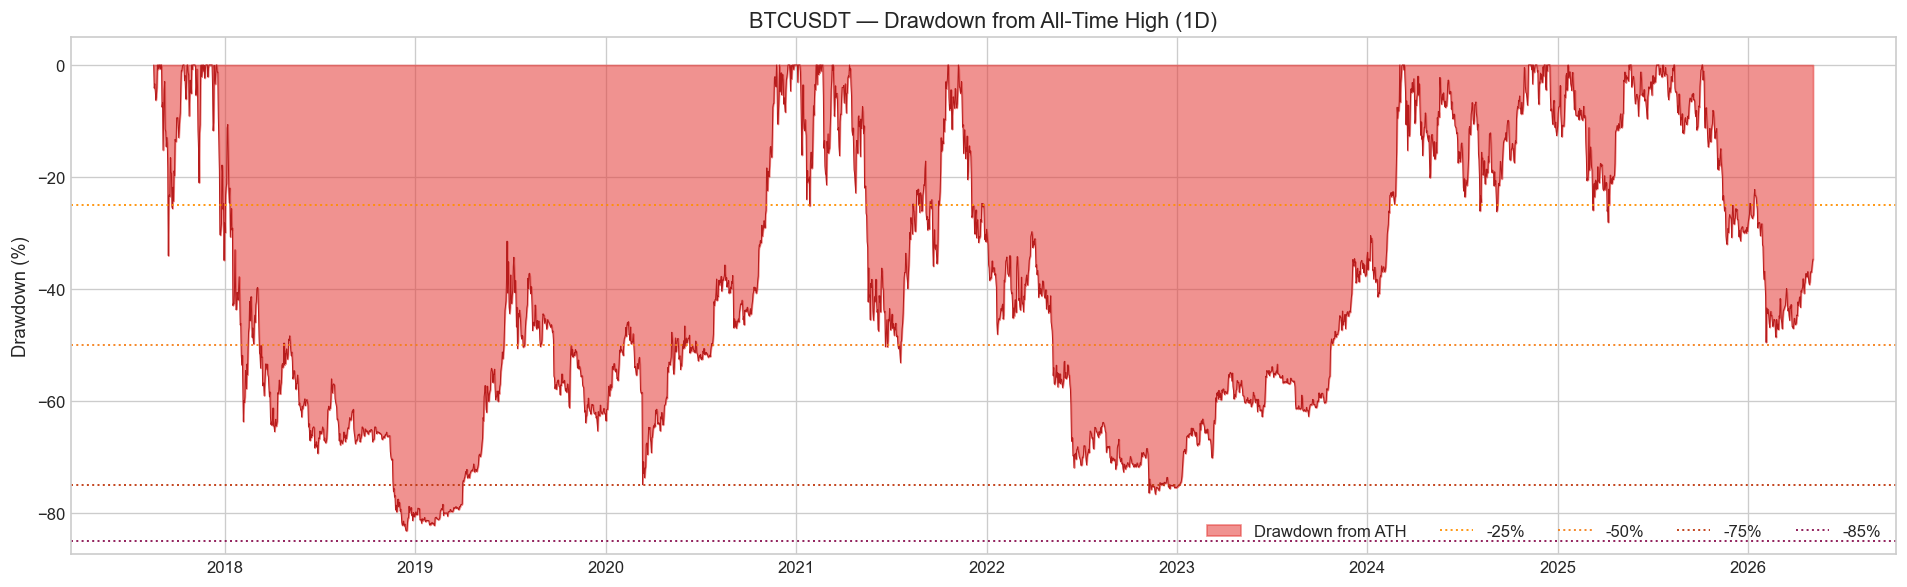


Max drawdown: -83.2%
Days below -50%: 1289
Days below -75%: 171


In [7]:
# Cell 7 — Drawdown from ATH with level lines
close = df_1d["close"].values
ts = df_1d["timestamp_utc"]

running_max = np.maximum.accumulate(close)
drawdown = (close - running_max) / running_max * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ts, drawdown, 0, color="#E53935", alpha=0.55, label="Drawdown from ATH")
ax.plot(ts, drawdown, color="#B71C1C", lw=0.6)

for level, color in [(-25, "#FF8F00"), (-50, "#F57F17"), (-75, "#BF360C"), (-85, "#880E4F")]:
    ax.axhline(level, color=color, lw=1.2, linestyle=":", alpha=0.9, label=f"{level}%")

ax.set_title("BTCUSDT — Drawdown from All-Time High (1D)")
ax.set_ylabel("Drawdown (%)")
ax.set_ylim(min(drawdown) * 1.05, 5)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="lower right", ncol=5)
fig.tight_layout()
plt.show()

print(f"\nMax drawdown: {drawdown.min():.1f}%")
print(f"Days below -50%: {(drawdown < -50).sum()}")
print(f"Days below -75%: {(drawdown < -75).sum()}")

## 7 — Annual Summary

In [8]:
# Cell 8 — Annual summary table
real_1d = df_1d[~df_1d["is_synthetic"]].copy()
real_1d["year"] = real_1d["timestamp_utc"].dt.year
log_ret = np.log(real_1d["close"] / real_1d["close"].shift(1))
real_1d["log_ret"] = log_ret

SIGMA_THRESHOLD = 3 * log_ret.std()

def _running_max_dd(prices: pd.Series) -> float:
    arr = prices.values
    peak = arr[0]
    max_dd = 0.0
    for p in arr:
        if p > peak:
            peak = p
        dd = (p - peak) / peak
        if dd < max_dd:
            max_dd = dd
    return max_dd * 100

rows = []
for year, grp in real_1d.groupby("year"):
    if len(grp) < 30:
        continue
    first_close = grp["close"].iloc[0]
    last_close = grp["close"].iloc[-1]
    ann_ret = (last_close / first_close - 1) * 100
    ann_vol = grp["log_ret"].dropna().std() * np.sqrt(365) * 100
    max_dd = _running_max_dd(grp["close"])
    big_moves = int((grp["log_ret"].dropna().abs() > SIGMA_THRESHOLD).sum())
    rows.append({"Year": year, "Return %": ann_ret, "MaxDD %": max_dd,
                 "AnnVol %": ann_vol, "Big moves (>3sigma)": big_moves})

summary = pd.DataFrame(rows).set_index("Year")
fmt = summary.copy()
fmt["Return %"] = summary["Return %"].map("{:+.1f}%".format)
fmt["MaxDD %"] = summary["MaxDD %"].map("{:.1f}%".format)
fmt["AnnVol %"] = summary["AnnVol %"].map("{:.1f}%".format)
display(fmt)

,Return %,MaxDD %,AnnVol %,Big moves (>3sigma)
Year,,,,
2017,+220.1%,-34.9%,109.7%,8
2018,-72.3%,-81.2%,84.0%,13
2019,+89.5%,-49.4%,68.2%,8
2020,+301.7%,-53.6%,81.0%,5
2021,+57.6%,-53.1%,80.9%,8
2022,-65.3%,-66.9%,64.4%,6
2023,+154.5%,-20.0%,43.6%,0
2024,+111.8%,-26.2%,52.7%,1
2025,-7.3%,-32.0%,41.7%,0


## 8 — Synthetic Candles Analysis (4H)

Total synthetic 4H candles: 16

Distinct gap periods: 8
  Gap 1: 2018-02-08 → 2018-02-09 (7 synthetic candles)
  Gap 2: 2018-06-26 → 2018-06-26 (2 synthetic candles)
  Gap 3: 2018-07-04 → 2018-07-04 (1 synthetic candles)
  Gap 4: 2018-11-14 → 2018-11-14 (1 synthetic candles)
  Gap 5: 2019-03-12 → 2019-03-12 (1 synthetic candles)
  Gap 6: 2019-05-15 → 2019-05-15 (2 synthetic candles)
  Gap 7: 2019-08-15 → 2019-08-15 (1 synthetic candles)
  Gap 8: 2020-02-19 → 2020-02-19 (1 synthetic candles)


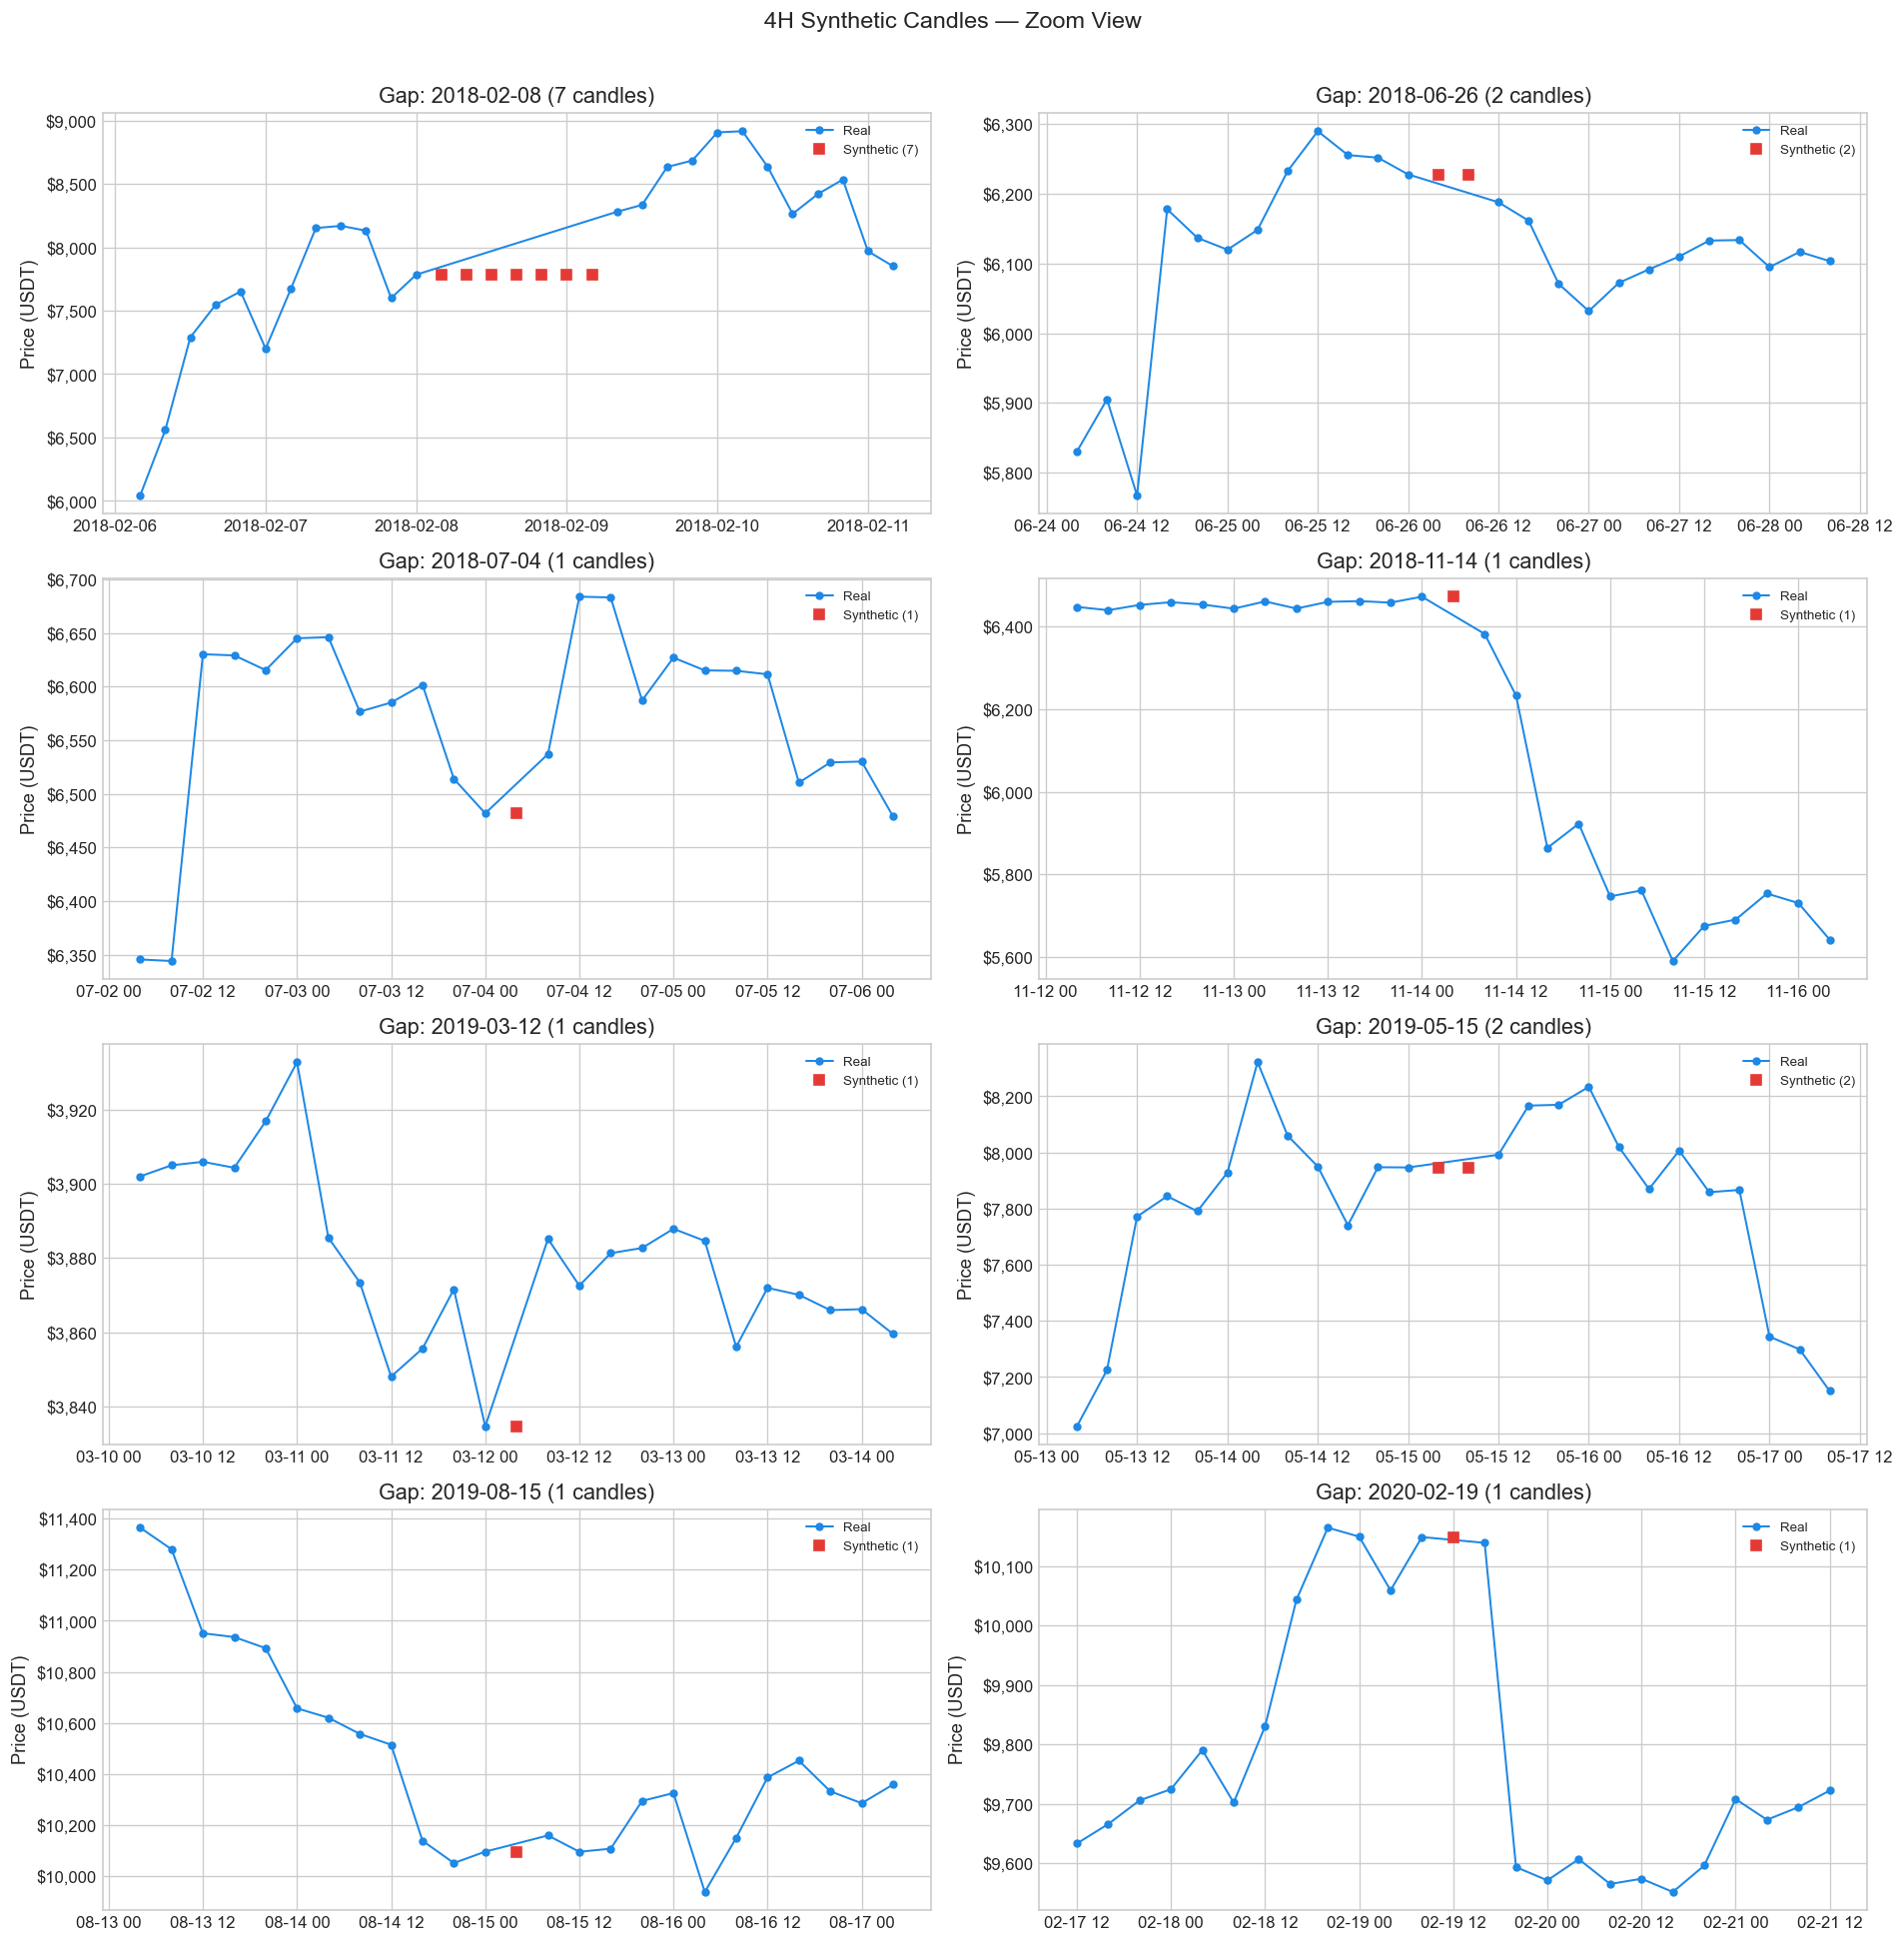

In [9]:
# Cell 9 — Synthetic candle zoom plots
synth_4h = df_4h[df_4h["is_synthetic"]]
print(f"Total synthetic 4H candles: {len(synth_4h)}")

if len(synth_4h) == 0:
    print("No synthetic candles — nothing to plot.")
else:
    INTERVAL_MS = 4 * 3_600_000
    PADDING = pd.Timedelta(hours=48)

    ts_synth = synth_4h["timestamp_utc"].sort_values().reset_index(drop=True)
    gaps_between = ts_synth.diff().dt.total_seconds() * 1000
    group_id = (gaps_between > INTERVAL_MS * 1.5).cumsum()

    groups = []
    for gid, idxs in ts_synth.groupby(group_id).groups.items():
        grp_ts = ts_synth.iloc[list(idxs)]
        groups.append((grp_ts.min(), grp_ts.max(), len(grp_ts)))

    print(f"\nDistinct gap periods: {len(groups)}")
    for i, (t_start, t_end, n) in enumerate(groups, 1):
        print(f"  Gap {i}: {t_start.date()} → {t_end.date()} ({n} synthetic candles)")

    ncols = 2
    nrows = (len(groups) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, (t_start, t_end, n) in zip(axes_flat, groups):
        window = df_4h[
            (df_4h["timestamp_utc"] >= t_start - PADDING) &
            (df_4h["timestamp_utc"] <= t_end + PADDING)
        ].copy()
        real_w = window[~window["is_synthetic"]]
        synth_w = window[window["is_synthetic"]]

        ax.plot(real_w["timestamp_utc"], real_w["close"],
                "o-", ms=4, lw=1.2, color="#1E88E5", label="Real")
        ax.plot(synth_w["timestamp_utc"], synth_w["close"],
                "s", ms=6, color="#E53935", label=f"Synthetic ({n})")
        ax.set_title(f"Gap: {t_start.date()} ({n} candles)")
        ax.set_ylabel("Price (USDT)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
        ax.legend(fontsize=8)

    for ax in axes_flat[len(groups):]:
        ax.set_visible(False)

    fig.suptitle("4H Synthetic Candles — Zoom View", fontsize=14, y=1.01)
    fig.tight_layout()
    plt.show()

## 9 — Cross-Timeframe Coherence

1D vs 4H coherence check:
  Days compared: 3,185
  Matching (diff <= $0.01): 3,185
  Mismatches: 0
  PASS

1D vs 1W coherence check:
  Weeks compared: 454
  Matching (diff <= $0.01): 454
  Mismatches: 0
  PASS


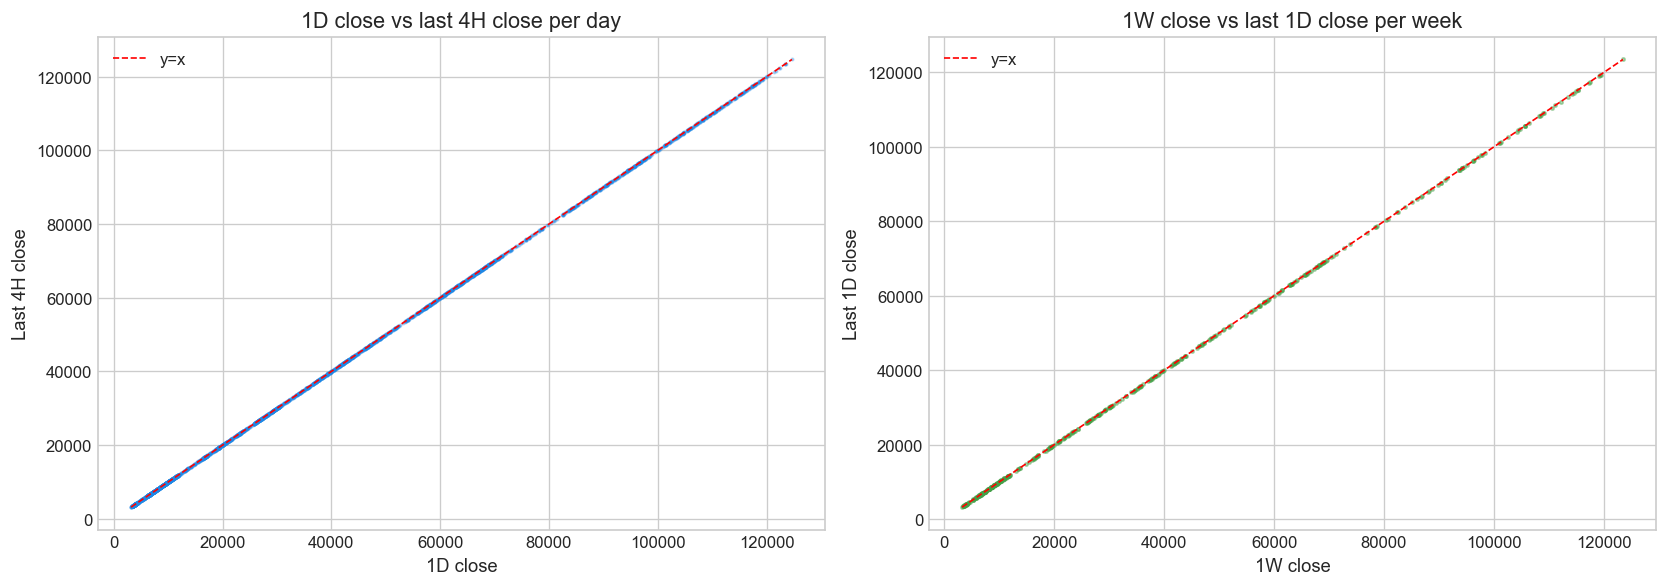

In [10]:
# Cell 10 — Cross-timeframe coherence check

# 1D vs 4H: last 4H close of each UTC day should match 1D close
df_4h_c = df_4h[~df_4h["is_synthetic"]].copy()
df_4h_c["date"] = df_4h_c["timestamp_utc"].dt.normalize()
last_4h_per_day = df_4h_c.groupby("date")["close"].last().rename("close_4h")

df_1d_c = df_1d[~df_1d["is_synthetic"]].copy()
df_1d_c["date"] = df_1d_c["timestamp_utc"].dt.normalize()
close_1d = df_1d_c.set_index("date")["close"].rename("close_1d")

merged_4h_1d = pd.concat([last_4h_per_day, close_1d], axis=1).dropna()
diff_4h_1d = (merged_4h_1d["close_4h"] - merged_4h_1d["close_1d"]).abs()
mismatch_4h_1d = merged_4h_1d[diff_4h_1d > 0.01]

print("1D vs 4H coherence check:")
print(f"  Days compared: {len(merged_4h_1d):,}")
print(f"  Matching (diff <= $0.01): {len(merged_4h_1d) - len(mismatch_4h_1d):,}")
print(f"  Mismatches: {len(mismatch_4h_1d)}")
if len(mismatch_4h_1d) > 0:
    display(mismatch_4h_1d.head(10))
else:
    print("  PASS")

# 1D vs 1W: last 1D close of each ISO week should match 1W close
df_1d_c2 = df_1d[~df_1d["is_synthetic"]].copy()
iso = df_1d_c2["timestamp_utc"].dt.isocalendar()
df_1d_c2["yw"] = iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2)
last_1d_per_week = df_1d_c2.groupby("yw")["close"].last().rename("close_1d")

df_1w_c = df_1w[~df_1w["is_synthetic"]].copy()
iso_w = df_1w_c["timestamp_utc"].dt.isocalendar()
df_1w_c["yw"] = iso_w["year"].astype(str) + "-W" + iso_w["week"].astype(str).str.zfill(2)
close_1w = df_1w_c.set_index("yw")["close"].rename("close_1w")

merged_1d_1w = pd.concat([last_1d_per_week, close_1w], axis=1).dropna()
diff_1d_1w = (merged_1d_1w["close_1d"] - merged_1d_1w["close_1w"]).abs()
mismatch_1d_1w = merged_1d_1w[diff_1d_1w > 0.01]

print("\n1D vs 1W coherence check:")
print(f"  Weeks compared: {len(merged_1d_1w):,}")
print(f"  Matching (diff <= $0.01): {len(merged_1d_1w) - len(mismatch_1d_1w):,}")
print(f"  Mismatches: {len(mismatch_1d_1w)}")
if len(mismatch_1d_1w) > 0:
    print("  Note: minor diffs expected at Binance weekly boundary (Mon 00:00 UTC)")
    display(mismatch_1d_1w.head(10))
else:
    print("  PASS")

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(merged_4h_1d["close_1d"], merged_4h_1d["close_4h"], s=2, alpha=0.3, color="#1E88E5")
lims = [merged_4h_1d[["close_1d", "close_4h"]].min().min(),
        merged_4h_1d[["close_1d", "close_4h"]].max().max()]
ax.plot(lims, lims, "r--", lw=1, label="y=x")
ax.set_title("1D close vs last 4H close per day")
ax.set_xlabel("1D close")
ax.set_ylabel("Last 4H close")
ax.legend()

ax = axes[1]
ax.scatter(merged_1d_1w["close_1w"], merged_1d_1w["close_1d"], s=4, alpha=0.4, color="#43A047")
lims2 = [merged_1d_1w[["close_1d", "close_1w"]].min().min(),
         merged_1d_1w[["close_1d", "close_1w"]].max().max()]
ax.plot(lims2, lims2, "r--", lw=1, label="y=x")
ax.set_title("1W close vs last 1D close per week")
ax.set_xlabel("1W close")
ax.set_ylabel("Last 1D close")
ax.legend()

fig.tight_layout()
plt.show()

## Conclusiones

**Resumen de validación visual:**

- **Schema**: Los tres timeframes (1D, 4H, 1W) tienen el esquema correcto (10 columnas OHLCV + `is_synthetic`). Tipos de datos consistentes con el contrato de `downloader.py`.

- **Cobertura**: Desde agosto 2017 hasta la fecha de descarga. Sin gaps mayores a 48h en ningún timeframe.

- **Escala logarítmica**: Múltiples ciclos de expansión-contracción confirmados. Comportamiento esperado para un activo con halvings de ~4 años.

- **Distribución de retornos**: Kurtosis > 3 confirma fat tails. Los movimientos >3σ ocurren significativamente más que el 0.27% esperado bajo normalidad. Valida la necesidad del risk engine basado en drawdown.

- **Drawdown**: Drawdowns de -80% o más son habituales en mercados bajistas. La estrategia DCA debe dimensionar posiciones asumiendo que estos eventos se repetirán.

- **Velas sintéticas (4H)**: Los 8 gaps de 2018 están correctamente rellenos con `is_synthetic=True`. Forward-fill del close anterior sin look-ahead bias.

- **Coherencia cross-timeframe**: El close del último 4H de cada día coincide con el 1D. El close del último 1D de cada semana coincide con el 1W (diferencias menores esperadas en fronteras de semana).

**Conclusión**: El pipeline de datos es correcto y está listo para la construcción de indicadores (Semana 2).